In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df = pd.read_csv("Desktop/ecommerce_transactions.csv")

In [24]:
df.head()

,Transaction_ID,User_Name,Age,Country,Product_Category,Purchase_Amount,Payment_Method,Transaction_Date
0,1,Ava Hall,63,Mexico,Clothing,780.69,Debit Card,2023-04-14
1,2,Sophia Hall,59,India,Beauty,738.56,PayPal,2023-07-30
2,3,Elijah Thompson,26,France,Books,178.34,Credit Card,2023-09-17
3,4,Elijah White,43,Mexico,Sports,401.09,UPI,2023-06-21
4,5,Ava Harris,48,Germany,Beauty,594.83,Net Banking,2024-10-29


In [26]:
grouped = df.groupby(['Country', 'Product_Category'])['Purchase_Amount'].sum().reset_index()

In [28]:
top_countries = grouped.groupby('Country')['Purchase_Amount'].sum().nlargest(10).index
grouped = grouped[grouped['Country'].isin(top_countries)]

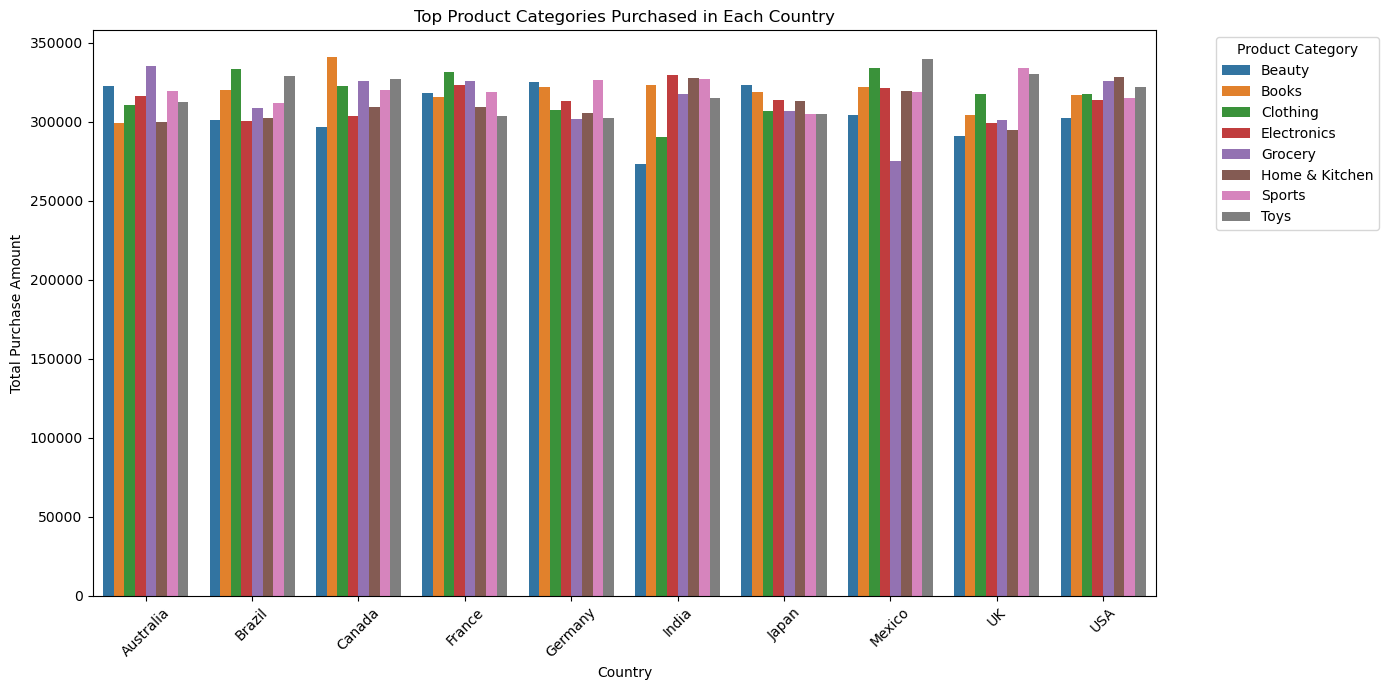

In [30]:
plt.figure(figsize=(14, 7))
sns.barplot(
    data=grouped,
    x='Country',
    y='Purchase_Amount',
    hue='Product_Category',
    palette='tab10'
)
plt.title("Top Product Categories Purchased in Each Country")
plt.xlabel("Country")
plt.ylabel("Total Purchase Amount")
plt.xticks(rotation=45)
plt.legend(title="Product Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

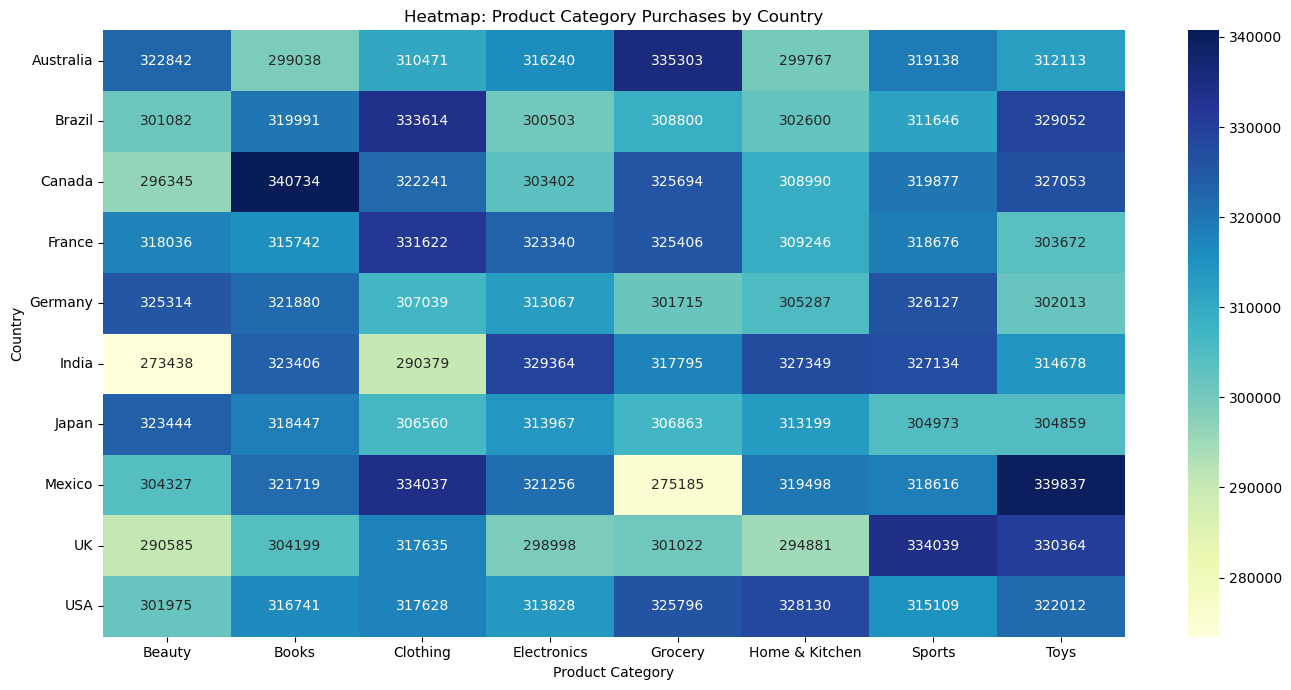


🔝 Most Purchased Product Category in Each Country:

          Product_Category  Purchase_Amount
Country                                    
Australia          Grocery        335303.16
Brazil            Clothing        333614.47
Canada               Books        340734.15
France            Clothing        331622.23
Germany             Sports        326127.36
India          Electronics        329364.17
Japan               Beauty        323443.64
Mexico                Toys        339836.63
UK                  Sports        334038.64
USA         Home & Kitchen        328129.75


In [32]:

pivot_data = grouped.pivot(index='Country', columns='Product_Category', values='Purchase_Amount').fillna(0)

plt.figure(figsize=(14, 7))
sns.heatmap(pivot_data, annot=True, fmt=".0f", cmap='YlGnBu')
plt.title("Heatmap: Product Category Purchases by Country")
plt.xlabel("Product Category")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

print("\n🔝 Most Purchased Product Category in Each Country:\n")
top_categories = grouped.sort_values('Purchase_Amount', ascending=False).groupby('Country').first()
print(top_categories[['Product_Category', 'Purchase_Amount']])
